In [23]:
import numpy as np 
import h5py
from pathlib import Path 
import IPython.display as ipd 
import pickle 
%matplotlib inline 
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import scipy.stats as stats
import src.statsmodels as statsmodels 
import copy


In [2]:
!ls binaural_unit_activations

word_task_half_co_loc_v08_gender_bal_4M_sanity
word_task_half_co_loc_v08_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout


In [6]:
model = "word_task_half_co_loc_v08_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout"

analysis_dir = Path(f"binaural_unit_activations/{model}")

h5_fn = analysis_dir / f"{model}_model_activations_0dB_time_avg.h5"

h5 = h5py.File(h5_fn, "r") 
print(h5.keys())
for key in h5.keys():
    print(key, h5[key].shape)
target_f0s = h5["target_f0"][:]
target_locs = h5["target_loc"][:]
# h5.close()

<KeysViewHDF5 ['attn0_target', 'attn1_gains', 'attn1_target', 'attn2_gains', 'attn2_target', 'attn3_gains', 'attn3_target', 'attn4_gains', 'attn4_target', 'attn5_gains', 'attn5_target', 'attn6_gains', 'attn6_target', 'attncoch_gains', 'attnfc_gains', 'attnfc_target', 'cochleagram_cue', 'cochleagram_fg', 'conv_block_0_ln_cue', 'conv_block_0_ln_target', 'conv_block_0_relu_cue', 'conv_block_0_relu_target', 'conv_block_1_ln_cue', 'conv_block_1_ln_target', 'conv_block_1_relu_cue', 'conv_block_1_relu_target', 'conv_block_2_ln_cue', 'conv_block_2_ln_target', 'conv_block_2_relu_cue', 'conv_block_2_relu_target', 'conv_block_3_ln_cue', 'conv_block_3_ln_target', 'conv_block_3_relu_cue', 'conv_block_3_relu_target', 'conv_block_4_ln_cue', 'conv_block_4_ln_target', 'conv_block_4_relu_cue', 'conv_block_4_relu_target', 'conv_block_5_ln_cue', 'conv_block_5_ln_target', 'conv_block_5_relu_cue', 'conv_block_5_relu_target', 'conv_block_6_ln_cue', 'conv_block_6_ln_target', 'conv_block_6_relu_cue', 'conv_blo

In [7]:
### Get layer shape dict 

layer_shape_dict = pickle.load(open(analysis_dir / f"{model}_layer_shape_dict_time_avg.pkl", "rb"))
# batch got saved, drop batch dim in layer_shape_dict
layer_shape_dict = {k: v[1:] for k,v in layer_shape_dict.items() if 'gains' not in k}

In [18]:
### Get model params to plot functions 
### Get most recent config

import yaml 
import torch
from src.spatial_attn_lightning import BinauralAttentionModule 

config_path = "config/binaural_attn/word_task_half_co_loc_v08_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout.yaml"
ckpt_path = "attn_cue_models/word_task_half_co_loc_v08_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout/checkpoints/epoch=4-step=59392.ckpt"
config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)
ckpt = torch.load(ckpt_path, map_location=torch.device('cpu'))
# for each ke in ckpt['state_dict'] remove ._orig_module from the key
new_state_dict = {}
for k, v in ckpt['state_dict'].items():
    if '_orig_mod.' in k:
        k = k.replace('_orig_mod.', '')
    new_state_dict[k] = v

ckpt['state_dict'] = new_state_dict
model = BinauralAttentionModule(config=config)

model.load_state_dict(ckpt['state_dict'])
attn_modules = model.attn_modules

Using explicit dim specification for demeaning in audio transforms
Using BinauralAuditoryAttentionCNN
v08 True
num_classes={'num_words': 800}
Model performing word task
Conv block order: LN -> Conv -> ReLU
coch_affine: True
center_crop=True
binaural=True
Binaural cochleagram
using FIR cochleagram


In [19]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def attn_gain(x, bias, slope, threshold):
    return bias + (1-bias) * sigmoid((x - threshold) * slope)
    
def get_sigmoid(cue_acts, module, n_bins=100, x=None):    
    x_for_fn = x if x is not None else np.linspace(np.abs(cue_acts).min(), np.abs(cue_acts).max(), n_bins)
    bias = module.bias.item()
    slope = module.slope.item()
    threshold = module.threshold.item() 
    return attn_gain(x_for_fn, bias, slope, threshold).T, x_for_fn
    

    

In [10]:
h5.keys()

<KeysViewHDF5 ['attn0_target', 'attn1_gains', 'attn1_target', 'attn2_gains', 'attn2_target', 'attn3_gains', 'attn3_target', 'attn4_gains', 'attn4_target', 'attn5_gains', 'attn5_target', 'attn6_gains', 'attn6_target', 'attncoch_gains', 'attnfc_gains', 'attnfc_target', 'cochleagram_cue', 'cochleagram_fg', 'conv_block_0_ln_cue', 'conv_block_0_ln_target', 'conv_block_0_relu_cue', 'conv_block_0_relu_target', 'conv_block_1_ln_cue', 'conv_block_1_ln_target', 'conv_block_1_relu_cue', 'conv_block_1_relu_target', 'conv_block_2_ln_cue', 'conv_block_2_ln_target', 'conv_block_2_relu_cue', 'conv_block_2_relu_target', 'conv_block_3_ln_cue', 'conv_block_3_ln_target', 'conv_block_3_relu_cue', 'conv_block_3_relu_target', 'conv_block_4_ln_cue', 'conv_block_4_ln_target', 'conv_block_4_relu_cue', 'conv_block_4_relu_target', 'conv_block_5_ln_cue', 'conv_block_5_ln_target', 'conv_block_5_relu_cue', 'conv_block_5_relu_target', 'conv_block_6_ln_cue', 'conv_block_6_ln_target', 'conv_block_6_relu_cue', 'conv_blo

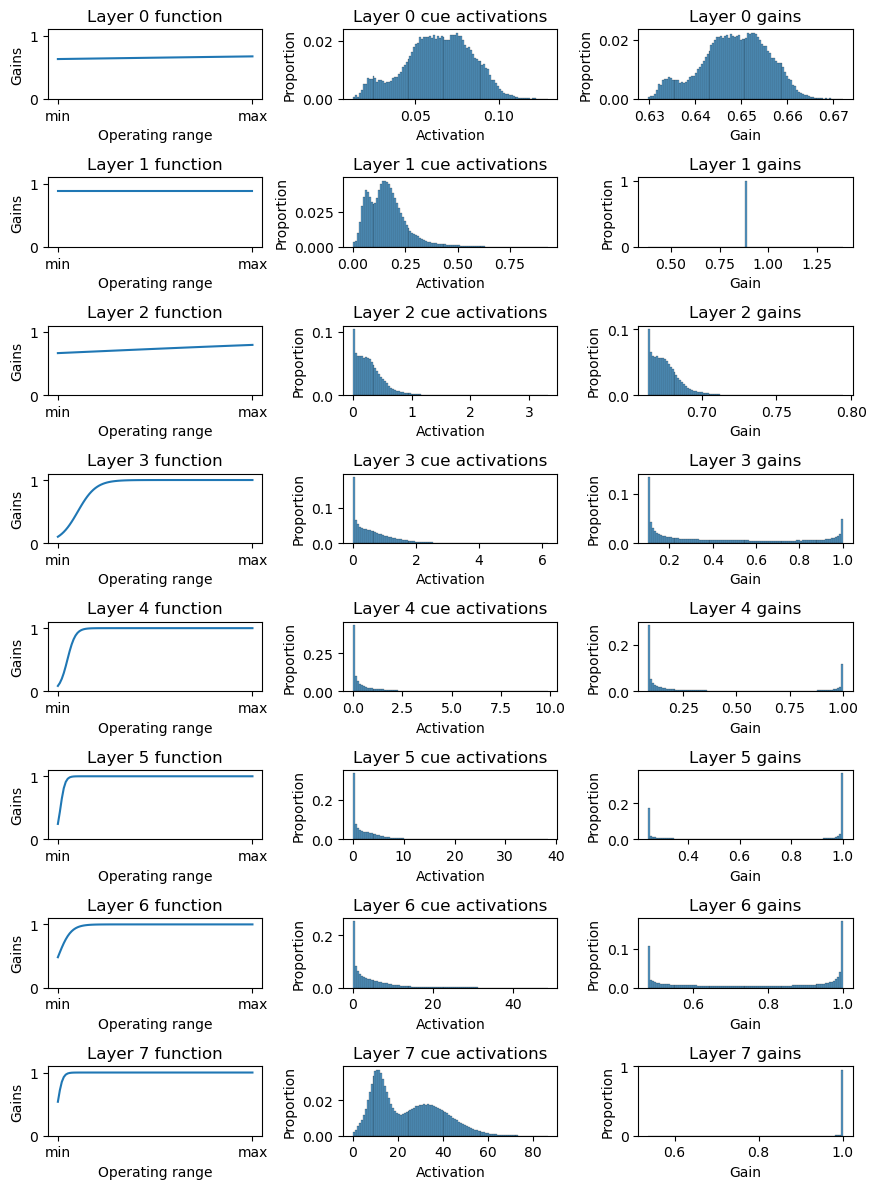

In [26]:
## Plot distribution of gains 
# gain_keys = [key for key in h5.keys() if "gain" in key]
act_keys = ['cochleagram_cue',
            "hann_pool_0_cue",
            "hann_pool_1_cue",
            "hann_pool_2_cue",
            "hann_pool_3_cue",
            "hann_pool_4_cue",
            "hann_pool_5_cue",
            "hann_pool_6_cue",
        ]
gain_keys = ['attncoch_gains',
'attn1_gains',
 'attn2_gains',
 'attn3_gains',
 'attn4_gains',
 'attn5_gains',
 'attn6_gains',
 'attnfc_gains']

# get number of subplots for gains 
n_gains = len(gain_keys)
n_rows = int(np.ceil(n_gains))
n_cols = 2
fig, axs = plt.subplots(n_rows, 3, figsize=(9, 12))

for ix, (attn_module, act, gain) in enumerate(zip(*[attn_modules, act_keys, gain_keys])):
    # get activations for gain function and cue activation histogram
    acts = h5[act][:].flatten()
    x_min, x_max = acts.min(), acts.max()
    sigmoid_y, sigmoid_x = get_sigmoid(acts, attn_module)
    # plot gain function 
    axs[ix,0].plot(sigmoid_x, sigmoid_y)
    axs[ix,0].set_title(f"Layer {ix} function")
    axs[ix,0].set_xlabel("Operating range")
    axs[ix,0].set_ylabel("Gains")
    axs[ix,0].set_ylim(0, 1.1)
    axs[ix,0].set_xticks([x_min, x_max])
    axs[ix,0].set_xticklabels(["min", "max"])

    # histogram of cue activations
    sns.histplot(data=acts, bins=100, stat='proportion', ax=axs[ix,1])
    axs[ix,1].set_title(f"Layer {ix} cue activations")
    axs[ix,1].set_xlabel("Activation")

    # histogram of gains 
    sns.histplot(data=h5[gain][:].flatten(), bins=100, stat='proportion', ax=axs[ix,2])
    axs[ix,2].set_title(f"Layer {ix} gains")
    axs[ix,2].set_xlabel("Gain")


plt.tight_layout()
